# Práctica 9

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import sys

sys.path.append("..")

from AI_algorithms.ml.unsupervised import KMeans

Considere el siguiente conjunto de datos:

$$
\begin{array}{|c||c|c|c|c|}
\hline
 & x_1 & x_2 & x_3 & x_4 \\
\hline
1 & 0 & 0 & 1 & 0 \\
2 & 0 & 0 & 0 & 1 \\
3 & 1 & 0 & 1 & 0 \\
4 & 0 & 1 & 1 & 1 \\
5 & 1 & 1 & 0 & 0 \\
6 & 0 & 0 & 1 & 1 \\
7 & 1 & 0 & 1 & 0 \\
8 & 1 & 1 & 0 & 1 \\
\hline
\end{array}
$$


In [2]:
X = np.array([
    [0,0,1,0],
    [0,0,0,1],
    [1,0,1,0],
    [0,1,1,1],
    [1,1,0,0],
    [0,0,1,1],
    [1,0,1,0],
    [1,1,0,1]
]).astype(float)
X.shape

(8, 4)

Aplique el algoritmo de agrupamiento k-means con k = 3.

1. Use como centroides iniciales los ejemplos 1, 2 y 3.

    a) Si hay empates, escoja el centroide con el menor índice.

    b) Si un grupo queda vacío en una iteración, el centroide no cambia para la siguiente iteración.

In [3]:
centroids = X[0:3]
kmeans = KMeans(n_clusters=3, max_iter=10)
kmeans.fit(X, centroids=centroids, verbose=True)

Iteration 1
Distances:
      C1     C2     C3
0  0.000  1.414  1.000
1  1.414  0.000  1.732
2  1.000  1.732  0.000
3  1.414  1.414  1.732
4  1.732  1.732  1.414
5  1.000  1.000  1.414
6  1.000  1.732  0.000
7  2.000  1.414  1.732
Centroids:
C1:    0.000    0.333    1.000    0.667
C2:    0.500    0.500    0.000    1.000
C3:    1.000    0.333    0.667    0.000


Converged after 2 iterations.


In [4]:
clusters = kmeans.predict(X)
X_df = pd.DataFrame(X, columns=[f'x{i+1}' for i in range(X.shape[1])])
X_df['cluster'] = clusters
X_df

,x1,x2,x3,x4,cluster
0,0.0,0.0,1.0,0.0,0
1,0.0,0.0,0.0,1.0,1
2,1.0,0.0,1.0,0.0,2
3,0.0,1.0,1.0,1.0,0
4,1.0,1.0,0.0,0.0,2
5,0.0,0.0,1.0,1.0,0
6,1.0,0.0,1.0,0.0,2
7,1.0,1.0,0.0,1.0,1


In [5]:
print(f'Model inertia: {kmeans.inertia_:.3f}')

Model inertia: 3.667


---

### Extra

Vamos a evaaluar este ejercicio en un dataset sintetico con 4 clusters para identificar el codo.

In [6]:
X, y = make_blobs(n_samples=100, centers=3, cluster_std=0.6, random_state=30)
print(X.shape, y.shape)

(100, 2) (100,)


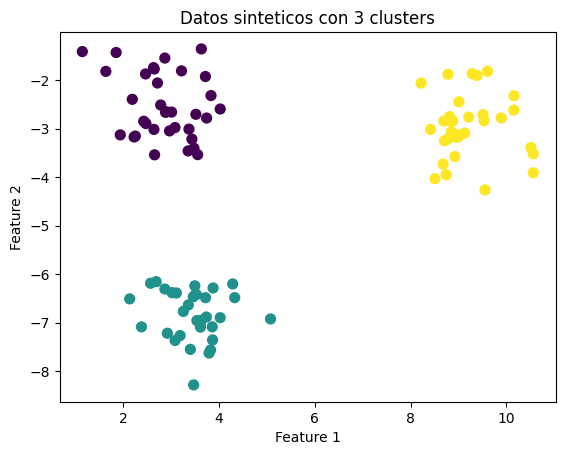

In [7]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
plt.title("Datos sinteticos con 3 clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [8]:
models = []
inertia_values = []
for n_clusters in range(1, 10):
    kmeans = KMeans(n_clusters=n_clusters, max_iter=100, tol=1e-8, random_state=42)
    kmeans.fit(X, verbose=False)
    models.append(kmeans)
    inertia_values.append(kmeans.inertia_)
    print(f'KMeans with {n_clusters} clusters fitted')

KMeans with 1 clusters fitted
KMeans with 2 clusters fitted
KMeans with 3 clusters fitted
KMeans with 4 clusters fitted
KMeans with 5 clusters fitted
KMeans with 6 clusters fitted
KMeans with 7 clusters fitted
KMeans with 8 clusters fitted
KMeans with 9 clusters fitted


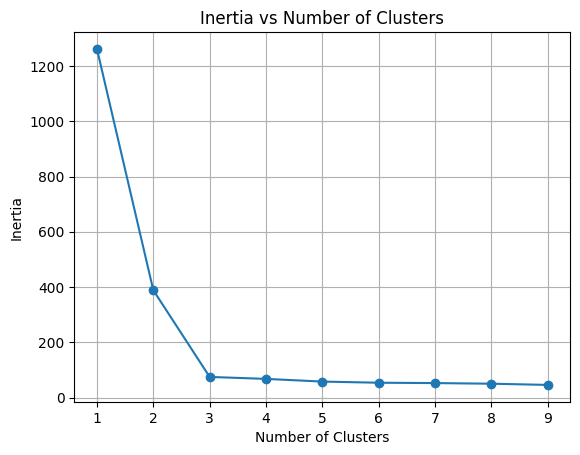

In [9]:
plt.plot(range(1, 10), inertia_values, marker='o')
plt.title("Inertia vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(1, 10))
plt.grid()
plt.show()

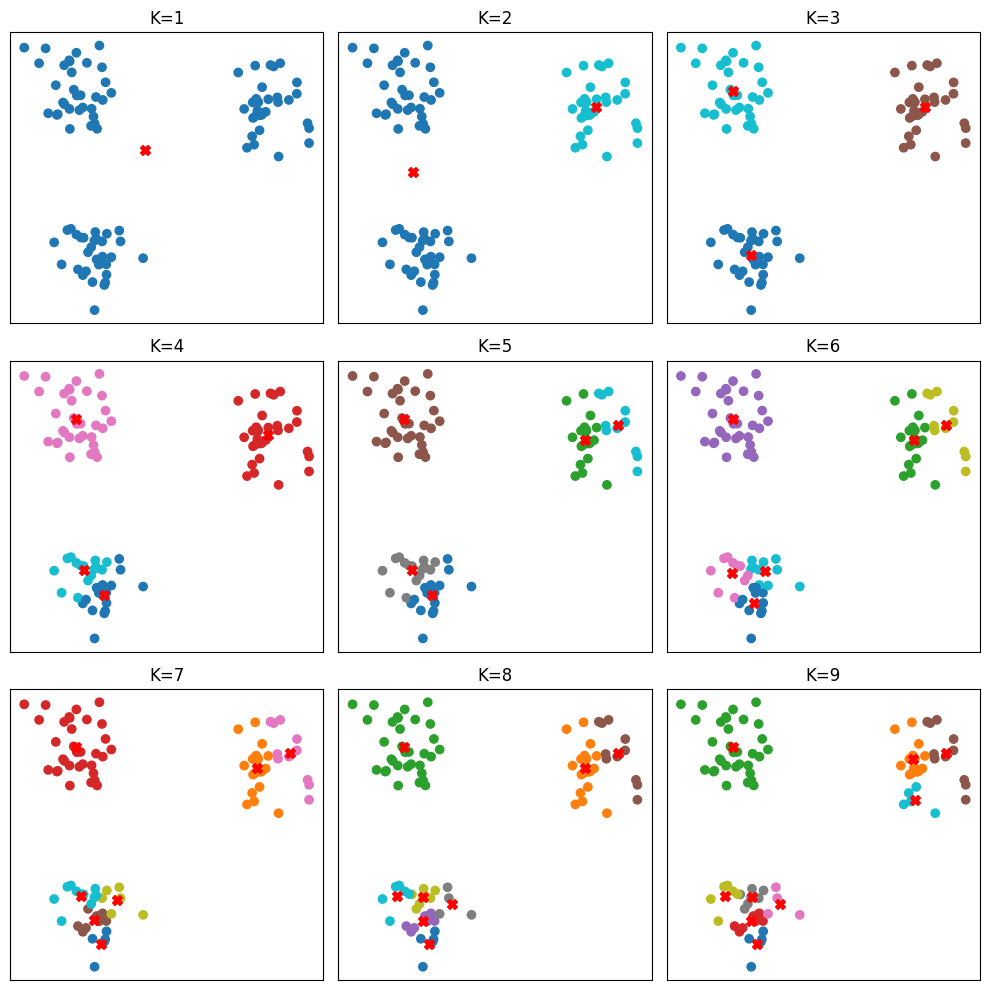

In [10]:
plt.figure(figsize=(10, 10))
for i, model in enumerate(models):
    plt.subplot(3, 3, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=model.predict(X), cmap='tab10')
    plt.scatter(model.centroids[:, 0], model.centroids[:, 1], c='red', s=50, marker='X')
    plt.title(f'K={model.n_clusters}')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()